<font color='Red'>In the Name of God</font>

# <font color='SlateBlue'>Data Science CA 5&6: Task#1</font>

<font color='grass'>Aidin Kazemi: 810101561</font>

<font color='grass'>Ali Zilouchi: 810101560</font>

<font color='grass'>Paria Pasehvarz: 810101561</font>

## <font color='MediumOrchid'>Part 1: Text Vectorization</font>

### <font color='Thistle'>1. Installing, Importing, Downloading</font>

Before performing text vectorization, we need specific libraries and files.

* **sentence-transformers**: For pre-trained sentence embeddings.
* **gensim**: For Word2Vec training and inference.
* **scikit-learn**: For PCA dimensionality reduction.
* **matplotlib** & **seaborn**: For visualization.

In [ ]:
import os

if not os.path.exists('flag'):

  !pip install sentence-transformers gensim scikit-learn matplotlib seaborn

  !gdown 1tSGZk0WJ1gleCqfbK3sYT_HhJfwJ7qLa

  !gdown 1mKS4A_lythfdCsj7XqkVsizrw3Rdo8N7

  !touch flag

### <font color='Thistle'>2. Loading the Datasets</font>

We load the **labeled** and **unlabeled** review datasets.

* The **labeled dataset** has `review_text` and `review_score`.
* The **unlabeled dataset** only has `review_text`.
  These will later be used for training embeddings and visualization.


In [ ]:
import pandas as pd

# Load datasets
labeled_df = pd.read_csv("labeled-data.csv")
unlabeled_df = pd.read_csv("unlabeled-data.csv")

# Combine both datasets for certain embedding tasks
all_texts = pd.concat([labeled_df["review_text"], unlabeled_df["review_text"]], ignore_index=True)

labeled_df.head()

,review_text,review_score
0,"It&#146;s the best looking, most enticingly pu...",8
1,The Nintendo LABO Variety Kit has some fun and...,8
2,"But as far as sound investments go, buying up ...",8
3,"Starts out with a bang, but then quickly falls...",7
4,Valkyria Revolution tells a decent tale of war...,6


### <font color='Thistle'>3. SentenceTransformer Embeddings</font>

We use **SentenceTransformer** (`all-MiniLM-L6-v2`) to create dense semantic embeddings.

* These embeddings capture meaning at the **sentence level**, making them powerful for semantic tasks.
* We generate embeddings for both labeled and unlabeled datasets.

In [ ]:
from sentence_transformers import SentenceTransformer

# Load pre-trained model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Compute embeddings
labeled_embeddings_st = model.encode(labeled_df["review_text"].tolist(), show_progress_bar=True)
unlabeled_embeddings_st = model.encode(unlabeled_df["review_text"].tolist(), show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

### <font color='Thistle'>4. Training Word2Vec on Combined Corpus</font>

Now we use **Word2Vec** to learn distributed word embeddings.

* Word2Vec captures **word-level semantics** based on context.
* To get **sentence-level embeddings**, we average the vectors of all words in each review.
* We train on both labeled and unlabeled reviews to maximize coverage.


In [ ]:
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
nltk.download("punkt")
nltk.download("punkt_tab")


# Tokenize the reviews
tokenized_corpus = [word_tokenize(text.lower()) for text in all_texts]

# Train Word2Vec model
w2v_model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=2, workers=4)

# Function to compute average Word2Vec embedding for a sentence
import numpy as np

def get_w2v_embedding(text, model):
    tokens = word_tokenize(text.lower())
    valid_tokens = [token for token in tokens if token in model.wv]
    if not valid_tokens:
        return np.zeros(model.vector_size)  # handle empty case
    return np.mean(model.wv[valid_tokens], axis=0)

# Compute embeddings
labeled_embeddings_w2v = np.array([get_w2v_embedding(text, w2v_model) for text in labeled_df["review_text"]])
unlabeled_embeddings_w2v = np.array([get_w2v_embedding(text, w2v_model) for text in unlabeled_df["review_text"]])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### <font color='Thistle'>5. Dimensionality Reduction with PCA</font>

Sentence embeddings are high-dimensional (384 for SentenceTransformer, 100 for Word2Vec).
To visualize them, we reduce dimensions to **2D using PCA**.
This allows us to create scatter plots to see if clusters form by review score.

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA on SentenceTransformer embeddings
pca_st = PCA(n_components=2)
labeled_pca_st = pca_st.fit_transform(labeled_embeddings_st)

# Apply PCA on Word2Vec embeddings
pca_w2v = PCA(n_components=2)
labeled_pca_w2v = pca_w2v.fit_transform(labeled_embeddings_w2v)

### <font color='Thistle'>6. Visualization of Embeddings</font>

We plot the reduced embeddings in 2D.

* Each point represents a review.
* Color corresponds to the **review score** (1–10).
* If clusters are visible, embeddings are capturing score-related patterns.

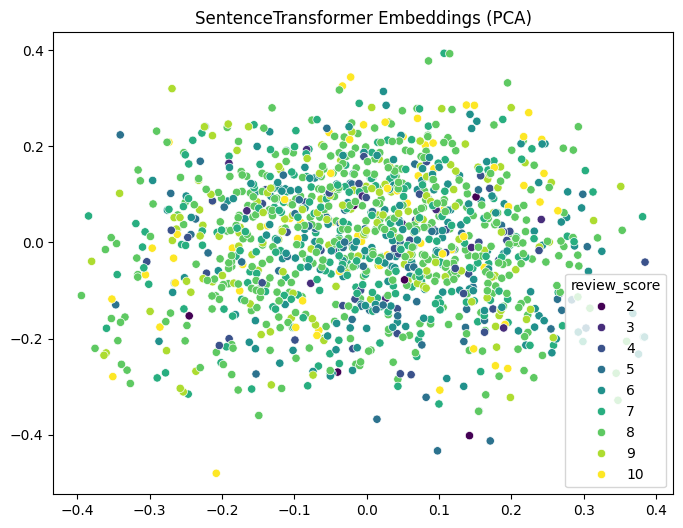

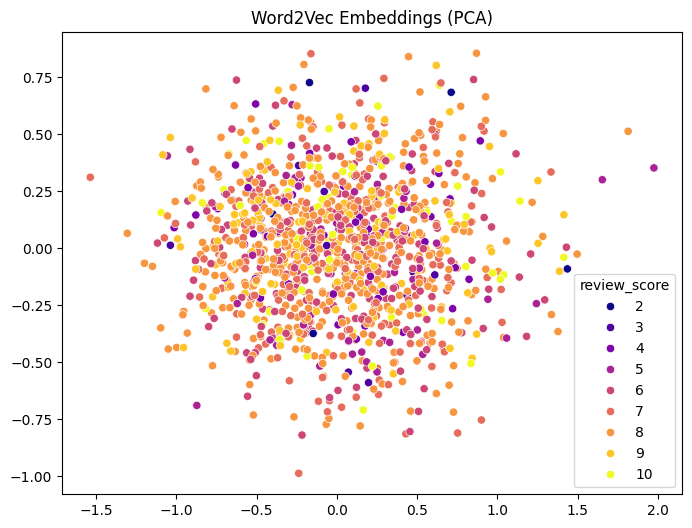

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot SentenceTransformer embeddings
plt.figure(figsize=(8,6))
sns.scatterplot(x=labeled_pca_st[:,0], y=labeled_pca_st[:,1], hue=labeled_df["review_score"], palette="viridis", legend="full")
plt.title("SentenceTransformer Embeddings (PCA)")
plt.show()

# Plot Word2Vec embeddings
plt.figure(figsize=(8,6))
sns.scatterplot(x=labeled_pca_w2v[:,0], y=labeled_pca_w2v[:,1], hue=labeled_df["review_score"], palette="plasma", legend="full")
plt.title("Word2Vec Embeddings (PCA)")
plt.show()

### <font color='Thistle'>7. Why Clusters Might Not Be Clear</font>

Even after PCA, embeddings do **not show distinct clusters**. Possible reasons:

1. **Information loss**: PCA reduces dimensions and may discard nuances, specially in 2D case.
2. **Semantic overlap**: Reviews with very different scores may still use similar words.
3. **Subjectivity**: Scores depend on personal opinion, which may not directly align with wording.
4. **Small labeled dataset**: Limited data makes it harder to see clear trends.

## <font color='MediumOrchid'>Part 2: Supervised Learning Baselines</font>

### <font color='Thistle'>1) Make X and y for The supervised models</font>

In [ ]:
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA

X_raw = labeled_embeddings_st
y     = labeled_df["review_score"].astype(int).to_numpy()

n_components = 100

norm = Normalizer('l2')
X_norm = norm.fit_transform(X_raw)

pca = PCA(n_components=n_components, random_state=42)
X = pca.fit_transform(X_norm)

print("X.shape, y.shape ->", X.shape, y.shape)
print(f"PCA: {pca.n_components_} comps, explained variance={pca.explained_variance_ratio_.sum():.3f}")


X.shape, y.shape -> (1250, 100) (1250,)
PCA: 100 comps, explained variance=0.761


### <font color='Thistle'>2) Split into train (80%), validation (10%), test (10%)</font>

We perform a stratified split by score to preserve class balance. We’ll split 80/20, then split the 20 into 10/10 for val/test.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter

# 1) Show class distribution
counts = Counter(y)
print("Per-class counts:", dict(sorted(counts.items())))
min_class, min_count = min(counts.items(), key=lambda kv: kv[1])
print(f"Least populated class: {min_class} -> {min_count} example(s)")

def safe_train_test_split(X, y, test_size, random_state, try_stratify=True):
    """Try a stratified split; if it fails due to rare classes, fallback to non-stratified."""
    stratify_y = y if try_stratify else None
    try:
        return train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=stratify_y
        )
    except ValueError as e:
        print(f"[WARN] Stratified split failed ({e}). Falling back to non-stratified split.")
        return train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=None
        )

# 2) First split: 80% train, 20% temp (try stratified)
X_train, X_temp, y_train, y_temp = safe_train_test_split(
    X, y, test_size=0.20, random_state=42, try_stratify=True
)

# 3) Second split: 10% val, 10% test from temp (try stratified again; can fail if tiny classes exist)
X_val, X_test, y_val, y_test = safe_train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, try_stratify=True
)

print("Shapes ->",
      "Train:", X_train.shape,
      "Val:", X_val.shape,
      "Test:", X_test.shape)


Per-class counts: {2: 6, 3: 12, 4: 52, 5: 66, 6: 188, 7: 241, 8: 452, 9: 162, 10: 71}
Least populated class: 2 -> 6 example(s)
[WARN] Stratified split failed (The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.). Falling back to non-stratified split.
Shapes -> Train: (1000, 100) Val: (125, 100) Test: (125, 100)


### <font color='Thistle'>3) Train **classification** baselines (LogReg, Linear SVC, RandomForest)</font>

We’ll try three strong, simple baselines:

* **Logistic Regression** (multinomial)
* **Linear SVC** (one-vs-rest)
* **RandomForestClassifier**
  We standardize features where it matters (linear models), evaluate on **validation** with macro‑averaged F1, keep the **best model**, then finalize metrics on the **test** set: Accuracy, Precision (macro), Recall (macro), F1 (macro), and a Confusion Matrix.

Train class counts: {2: 5, 3: 10, 4: 42, 5: 53, 6: 150, 7: 193, 8: 361, 9: 129, 10: 57}

[Majority (VAL)] acc=0.3840  prec_m=0.0480  rec_m=0.1250  f1_m=0.0694

[Majority (TEST)] acc=0.3440  prec_m=0.0382  rec_m=0.1111  f1_m=0.0569
Val macro-F1: {'LogReg': 0.2237, 'LinearSVC': 0.1942, 'RandomForest': 0.0694}
Best on VAL: LogReg

[Best LogReg (TEST)] acc=0.2320  prec_m=0.1817  rec_m=0.2147  f1_m=0.1780

Classification report (TEST):
               precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.13      0.33      0.19         6
           6       0.21      0.26      0.23        19
           7       0.27      0.24      0.26        25
           8       0.44      0.16      0.24        43
           9       0.33      0.33      0.33        18
          10       0.25      0.60      0.35         5

    accuracy          

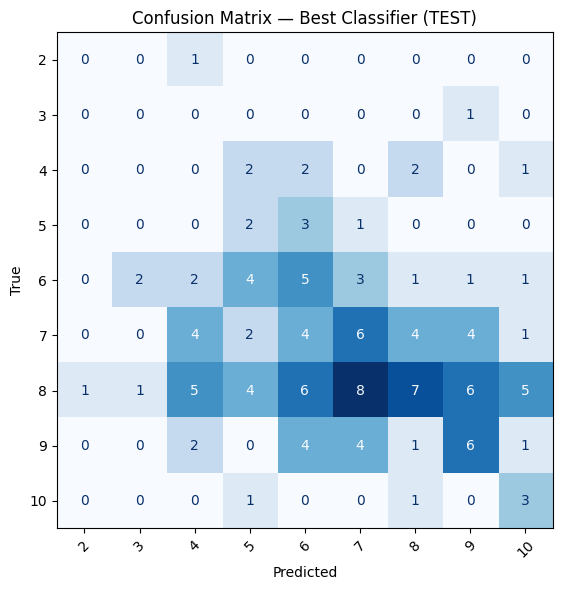

In [ ]:
from collections import Counter
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

# toggle if you want quick class rebalancing (kept OFF to keep results comparable)
USE_OVERSAMPLING = False

Xtr, ytr = X_train, y_train
if USE_OVERSAMPLING:
    try:
        from imblearn.over_sampling import RandomOverSampler
        Xtr, ytr = RandomOverSampler(random_state=42).fit_resample(X_train, y_train)
        print("Oversampling applied. New train counts:", dict(sorted(Counter(ytr).items())))
    except Exception as e:
        print("[oversampling skipped]", e)

print("Train class counts:", dict(sorted(Counter(y_train).items())))

# majority baseline (for justification)
maj = Counter(y_train).most_common(1)[0][0]
y_val_maj  = np.full_like(y_val,  maj)
y_test_maj = np.full_like(y_test, maj)

def summarize(tag, y_true, y_pred, *, as_dict=True):
    m = {
        "accuracy":        accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro":        f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    print(f"\n[{tag}] acc={m['accuracy']:.4f}  prec_m={m['precision_macro']:.4f}  "
          f"rec_m={m['recall_macro']:.4f}  f1_m={m['f1_macro']:.4f}")
    return m if as_dict else None

summarize("Majority (VAL)",  y_val,  y_val_maj)
summarize("Majority (TEST)", y_test, y_test_maj)

# three simple baselines
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=1.0, max_iter=2000, class_weight="balanced", random_state=42))
    ]),
    "LinearSVC": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=1.0, class_weight="balanced", random_state=42))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=400, class_weight="balanced", n_jobs=-1, random_state=42
    )
}

# select by validation macro-F1
val_f1, fitted = {}, {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    yvp = m.predict(X_val)
    val_f1[name] = f1_score(y_val, yvp, average="macro", zero_division=0)
    fitted[name] = m

best_name = max(val_f1, key=val_f1.get)
best_model = fitted[best_name]
print("Val macro-F1:", {k: round(v, 4) for k,v in val_f1.items()})
print("Best on VAL:", best_name)

# final test evaluation
ytp = best_model.predict(X_test)
clf_metrics = summarize(f"Best {best_name} (TEST)", y_test, ytp)
print("\nClassification report (TEST):\n", classification_report(y_test, ytp, zero_division=0))

# --- Confusion Matrix for the Best Classifier on TEST ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels_sorted = sorted(np.unique(y))  # ensure 1..10 ordering
cm = confusion_matrix(y_test, ytp, labels=labels_sorted)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
fig, ax = plt.subplots(figsize=(7,6))
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45, colorbar=False)
ax.set_title("Confusion Matrix — Best Classifier (TEST)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()

### <font color='Thistle'>4) Train **regression** baselines (Linear Regression, SVR, RandomForestRegressor)</font>

We’ll try three regressors and choose the best by **validation RMSE** (lower is better).
We then compute **MAE, MSE, RMSE, R²** on the **test** set.
We also derive an **integer prediction** by clipping to \[1,10] and rounding, just to compare how the regressor performs if turned into discrete scores.

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score
)

# Version-agnostic RMSE
def rmse_compat(y_true, y_pred):
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

# Candidates (scaled where needed)
reg_candidates = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0, random_state=42))
    ]),
    "Huber": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", HuberRegressor())  # robust to outliers
    ]),
    "SVR_rbf": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", SVR(kernel="rbf", C=3.0, epsilon=0.2))
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=400, max_depth=None, n_jobs=-1, random_state=42
    ),
}

# Select best on validation RMSE
val_rmse = {}
best_reg_name, best_model_reg, best_rmse = None, None, np.inf
for name, model in reg_candidates.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    rmse = rmse_compat(y_val, y_val_pred)
    val_rmse[name] = rmse
    if rmse < best_rmse:
        best_reg_name, best_model_reg, best_rmse = name, model, rmse

print("Validation RMSE per regressor (lower is better):",
      {k: round(v, 4) for k,v in sorted(val_rmse.items(), key=lambda x: x[1])})
print("Best regressor:", best_reg_name)

# Final test evaluation
y_test_pred = best_model_reg.predict(X_test)

reg_metrics = {
    "MAE":  mean_absolute_error(y_test, y_test_pred),
    "MSE":  mean_squared_error(y_test, y_test_pred),   # compat across versions
    "RMSE": rmse_compat(y_test, y_test_pred),
    "R2":   r2_score(y_test, y_test_pred),
}
print("\n=== Regression (Best on Test) ===")
for k, v in reg_metrics.items():
    print(f"{k}: {v:.4f}")

# Discrete view: clamp to [1,10] then round -> acts like a classifier
y_test_round = np.clip(np.rint(y_test_pred), 1, 10).astype(int)
rounded_metrics = {
    "accuracy":        accuracy_score(y_test, y_test_round),
    "precision_macro": precision_score(y_test, y_test_round, average="macro", zero_division=0),
    "recall_macro":    recall_score(y_test, y_test_round, average="macro", zero_division=0),
    "f1_macro":        f1_score(y_test, y_test_round, average="macro", zero_division=0),
}
print("\n=== Rounded-to-1..10 as Classifier (Test) ===")
for k, v in rounded_metrics.items():
    print(f"{k}: {v:.4f}")


Validation RMSE per regressor (lower is better): {'SVR_rbf': 1.1507, 'Ridge': 1.2303, 'LinearRegression': 1.2305, 'RandomForest': 1.2339, 'Huber': 1.234}
Best regressor: SVR_rbf

=== Regression (Best on Test) ===
MAE: 1.0649
MSE: 1.8175
RMSE: 1.3481
R2: 0.2384

=== Rounded-to-1..10 as Classifier (Test) ===
accuracy: 0.2640
precision_macro: 0.0953
recall_macro: 0.1258
f1_macro: 0.1032


### <font color='Thistle'>5) Comparative summary: classification vs. regression</font>

We’ll print a compact summary comparing the **best classifier** (by validation F1) and the **best regressor** (by validation RMSE, reported with regression metrics; plus its **rounded** classification metrics).

In [ ]:
print("\n================= COMPARATIVE SUMMARY =================")
print(f"Best Classifier: {best_name}")
for k,v in clf_metrics.items():
    print(f"  CLF {k}: {v:.4f}")

print(f"\nBest Regressor: {best_reg_name}")
for k,v in reg_metrics.items():
    print(f"  REG {k}: {v:.4f}")

print("\nRegressor (rounded to 1–10) used as classifier:")
for k,v in rounded_metrics.items():
    print(f"  REG->CLF {k}: {v:.4f}")



================= COMPARATIVE SUMMARY =================
Best Classifier: LogReg
  CLF accuracy: 0.2320
  CLF precision_macro: 0.1817
  CLF recall_macro: 0.2147
  CLF f1_macro: 0.1780

Best Regressor: SVR_rbf
  REG MAE: 1.0649
  REG MSE: 1.8175
  REG RMSE: 1.3481
  REG R2: 0.2384

Regressor (rounded to 1–10) used as classifier:
  REG->CLF accuracy: 0.2640
  REG->CLF precision_macro: 0.0953
  REG->CLF recall_macro: 0.1258
  REG->CLF f1_macro: 0.1032


**Notes:**
- Classification directly optimizes discrete label separation; macro-F1 balances all classes,
  which is helpful if some scores are underrepresented.
- Regression leverages ordinality (closeness of 7 vs 8), often improving MAE/RMSE but not
  necessarily translating into the best discrete accuracy after rounding.
- If the regressor produces values outside [1,10], clipping avoids invalid scores."


**Baseline:** Logistic Regression (balanced) on sentence embeddings for classification—best macro-F1 among classifiers and robust under class imbalance.

**Regression reference:** SVR (RBF)—lowest error (MAE/RMSE) and captures nonlinearity.

**Report:** We use LR as the superior model.

## <font color='MediumOrchid'>Part 3: Semi-Supervised Learning (SSL) Strategies</font>

### <font color='Thistle'>3.1 Pseudo‑Labeling </font>

We’ll start from our **best classification baseline** (LogisticRegression on sentence embeddings). Each round:

1. predict on the unlabeled pool,
2. take only **high‑confidence** predictions (≥ `conf_thr`),
3. add them to train,
4. retrain,
5. log test metrics.
   The loop stops early if nothing passes the threshold.

In [ ]:
from collections import Counter, defaultdict
import numpy as np
from sklearn.base import clone, is_classifier
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------- helpers ----------
def cls_metrics(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "prec_m": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "rec_m": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_m": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def _final_est(est):
    return est.steps[-1][1] if isinstance(est, Pipeline) else est

def ensure_classifier(model):
    if not is_classifier(_final_est(model)):
        raise TypeError(
            f"Pseudo-labeling loop is for classification. "
            f"Best model ends with a regressor: {_final_est(model).__class__.__name__}."
        )

def make_calibrated_clone(model, always=True):
    """Clone best_model and ensure final step is probabilistic (CalibratedClassifierCV)."""
    ensure_classifier(model)
    if isinstance(model, Pipeline):
        steps = [(name, clone(est)) for name, est in model.steps[:-1]]
        last_name, last_est = model.steps[-1]
        need_cal = always or not hasattr(last_est, "predict_proba")
        steps.append((last_name, CalibratedClassifierCV(clone(last_est), method="sigmoid", cv=3) if need_cal else clone(last_est)))
        return Pipeline(steps)
    est = clone(model)
    if always or not hasattr(est, "predict_proba"):
        est = CalibratedClassifierCV(est, method="sigmoid", cv=3)
    return est

def fit_with_weights(model, X, y, sample_weight):
    """Route sample_weight to final step if using Pipeline."""
    if isinstance(model, Pipeline):
        last_name = model.steps[-1][0]
        return model.fit(X, y, **{f"{last_name}__sample_weight": sample_weight})
    return model.fit(X, y, sample_weight=sample_weight)

# ---------- SSL settings (conservative) ----------
n_rounds = 6
start_thr, end_thr = 0.90, 0.98      # stricter to curb noise
top_k_fallback = 80                  # small seed if no item passes thr
max_add_per_round = 300              # fewer per round to keep quality high
quota_frac = 0.10                    # first pass: per-class quota = 10% of batch
cap_frac   = 0.25                    # second pass: per-class hard cap
alpha = 2.0                          # pseudo-label weight = (conf_score)**alpha
patience = 2                         # val patience

# ---------- working sets ----------
X_tr, y_tr = X_train.copy(), y_train.copy()

# Use the SAME fitted norm + pca from Part 2
X_pool = pca.transform(norm.transform(unlabeled_embeddings_st))
print("X_pool shape:", X_pool.shape)  # should be (*, 100)

# initialize sample weights: 1.0 for true labels
weights = np.ones(len(X_tr), dtype=float)
classes = np.unique(y_train)
n_classes = len(classes)

history, best_val_f1, bad_rounds = [], -1.0, 0

for r in range(1, n_rounds + 1):
    # 1) Fit calibrated clone of your best model with weights
    ssl_model = make_calibrated_clone(best_model, always=True)
    fit_with_weights(ssl_model, X_tr, y_tr, weights)

    # 2) Track VAL (gate) and TEST (report)
    yv = ssl_model.predict(X_val)
    val_m = cls_metrics(y_val, yv)
    yt = ssl_model.predict(X_test)
    test_m = cls_metrics(y_test, yt)

    history.append({
        "round": r,
        "labeled_size": len(X_tr),
        "val_f1_m": val_m["f1_m"], "val_acc": val_m["acc"],
        "test_f1_m": test_m["f1_m"], "test_acc": test_m["acc"],
    })
    print(f"[Round {r}] Using best model | Labeled {len(X_tr)} | "
          f"VAL f1_m={val_m['f1_m']:.4f} | TEST f1_m={test_m['f1_m']:.4f}")

    # early stop
    if val_m["f1_m"] > best_val_f1 + 1e-6:
        best_val_f1, bad_rounds = val_m["f1_m"], 0
    else:
        bad_rounds += 1
        if bad_rounds > patience:
            print("Early stop: validation did not improve.")
            break

    if len(X_pool) == 0:
        print("Unlabeled pool exhausted.")
        break

    # 3) Score pool → probs + margin-aware confidence
    proba = ssl_model.predict_proba(X_pool)
    p1 = proba.max(axis=1)
    arg1 = proba.argmax(axis=1)
    # second-best prob
    part = np.partition(proba, -2, axis=1)
    p2 = part[:, -2]
    margin = p1 - p2
    conf_score = 0.5 * p1 + 0.5 * margin

    # adaptive threshold
    thr = start_thr + (end_thr - start_thr) * (r - 1) / max(1, n_rounds - 1)
    cand = np.where(conf_score >= thr)[0]
    mode = f"thr={thr:.2f}"
    if cand.size == 0:
        mode = f"top-{top_k_fallback}"
        cand = np.argsort(conf_score)[::-1][:min(top_k_fallback, len(conf_score))]

    # rank by confidence desc
    cand = cand[np.argsort(conf_score[cand])[::-1]]

    # 4) Balanced selection: per-class quota, then fill with cap
    quota = max(1, int(quota_frac * max_add_per_round))
    cap   = max(1, int(cap_frac   * max_add_per_round))

    picked = []
    taken_per_class = defaultdict(int)

    # pass 1: per-class quota
    for c in classes:
        idx_c = [i for i in cand if arg1[i] == c]
        take = idx_c[:quota]
        picked.extend(take)
        taken_per_class[c] += len(take)
        if len(picked) >= max_add_per_round:
            break

    # pass 2: fill remainder under per-class cap
    if len(picked) < max_add_per_round:
        already = set(picked)
        for i in cand:
            if i in already:
                continue
            c = arg1[i]
            if taken_per_class[c] < cap:
                picked.append(i)
                taken_per_class[c] += 1
                if len(picked) >= max_add_per_round:
                    break

    if not picked:
        print(f"Candidates via {mode}, but none passed quota/cap. Stopping.")
        break

    picked = np.array(picked, dtype=int)
    # 5) Merge with confidence weights
    X_new = X_pool[picked]
    y_new = arg1[picked]
    w_new = np.power(conf_score[picked], alpha)

    # log
    dist = {int(k): int(v) for k, v in taken_per_class.items() if v > 0}
    print(f"Round {r}: added {len(picked)} via {mode}; "
          f"median conf={np.median(conf_score[picked]):.3f} | class dist: {dist}")

    X_tr = np.vstack([X_tr, X_new])
    y_tr = np.concatenate([y_tr, y_new])
    weights = np.concatenate([weights, w_new])

    # remove from pool
    keep = np.ones(len(X_pool), dtype=bool)
    keep[picked] = False
    X_pool = X_pool[keep]

# final model + TEST
final_model = make_calibrated_clone(best_model, always=True)
fit_with_weights(final_model, X_tr, y_tr, weights)
y_test_final = final_model.predict(X_test)
final_test_metrics = cls_metrics(y_test, y_test_final)
print("\nFinal TEST metrics:", final_test_metrics)

# optional: history as a small table
import pandas as pd
print(pd.DataFrame(history))


X_pool shape: (5000, 100)
[Round 1] Using best model | Labeled 1000 | VAL f1_m=0.0694 | TEST f1_m=0.0569
Round 1: added 75 via top-80; median conf=0.321 | class dist: {6: 75}
[Round 2] Using best model | Labeled 1075 | VAL f1_m=0.0694 | TEST f1_m=0.0569
Round 2: added 75 via top-80; median conf=0.313 | class dist: {6: 75}
[Round 3] Using best model | Labeled 1150 | VAL f1_m=0.0694 | TEST f1_m=0.0569
Round 3: added 75 via top-80; median conf=0.301 | class dist: {6: 75}
[Round 4] Using best model | Labeled 1225 | VAL f1_m=0.0694 | TEST f1_m=0.0569
Early stop: validation did not improve.

Final TEST metrics: {'acc': 0.344, 'prec_m': 0.03822222222222222, 'rec_m': 0.1111111111111111, 'f1_m': 0.056878306878306875}
   round  labeled_size  val_f1_m  val_acc  test_f1_m  test_acc
0      1          1000  0.069364    0.384   0.056878     0.344
1      2          1075  0.069364    0.384   0.056878     0.344
2      3          1150  0.069364    0.384   0.056878     0.344
3      4          1225  0.0693

### <font color='Thistle'>3.2 Active Learning</font>

Active Learning adds labels **strategically** instead of randomly. We **simulate** a human oracle by hiding most of the training labels and only “revealing” them when the algorithm queries them. We compare several classic query strategies:

* **Least Confidence:** pick points with the lowest max class probability.
* **Margin Sampling:** pick points with the smallest gap between the top-2 class probabilities.
* **Entropy Sampling:** pick points with the highest predictive entropy.

We start from a **tiny, stratified seed** from the original training fold, repeatedly:

1. train a calibrated classifier (so we have reliable probabilities),
2. score uncertainty on the pool,
3. query a small batch by a chosen strategy,
4. “reveal” their true labels (oracle),
5. add to training, and
6. track **VAL/TEST macro-F1** over rounds.

> Note: We only use the original **labeled** training fold for the AL simulation (so we can compute oracle labels). Our truly **unlabeled** CSV needs a real human to annotate; that’s outside this notebook’s scope by design.


**(Optional) quick experiment switch:** change `al_strategy` to `"least_confidence"` or `"entropy"` and rerun that block to compare curves.


In [ ]:
# ============================
# Part 3.2 — Active Learning
# ============================
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline

rng = np.random.default_rng(42)

def _final_estimator(est):
    return est.steps[-1][1] if isinstance(est, Pipeline) else est

def make_probabilistic(model, cv=3):
    """Clone 'best_model' and ensure it exposes predict_proba via calibration if needed."""
    if isinstance(model, Pipeline):
        steps = [(n, clone(e)) for n, e in model.steps[:-1]]
        last_name, last_est = model.steps[-1]
        if hasattr(last_est, "predict_proba"):
            steps.append((last_name, clone(last_est)))
            return Pipeline(steps)
        else:
            steps.append((last_name, CalibratedClassifierCV(clone(last_est), method="sigmoid", cv=cv)))
            return Pipeline(steps)
    est = clone(model)
    if hasattr(est, "predict_proba"):
        return est
    return CalibratedClassifierCV(est, method="sigmoid", cv=cv)

def macro_f1(y_true, y_pred):
    from sklearn.metrics import f1_score
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

def acc_prec_rec_f1(y_true, y_pred):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    return {
        "acc": accuracy_score(y_true, y_pred),
        "prec_m": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "rec_m": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_m": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def uncertainty_scores(proba, strategy="margin"):
    """
    Returns an array 's' where:
      - For 'margin': smaller is more uncertain (we will sort ascending)
      - For 'least_confidence' and 'entropy': larger is more uncertain (we will sort descending)
    """
    import numpy as np
    if strategy == "least_confidence":
        s = 1.0 - proba.max(axis=1)
        return s, "desc"
    elif strategy == "margin":
        part = np.partition(proba, -2, axis=1)
        p1 = part[:, -1]
        p2 = part[:, -2]
        s = p1 - p2  # smaller margin => higher uncertainty
        return s, "asc"
    elif strategy == "entropy":
        eps = 1e-12
        p = np.clip(proba, eps, 1 - eps)
        s = -(p * np.log(p)).sum(axis=1)
        return s, "desc"
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

# --------- Build a small seed set from X_train/y_train (simulation) ---------
classes = np.unique(y_train)
per_class_seed = 3  # you can tune this
seed_idx = []

for c in classes:
    idx_c = np.where(y_train == c)[0]
    k = min(per_class_seed, len(idx_c))
    if k > 0:
        pick = rng.choice(idx_c, size=k, replace=False)
        seed_idx.extend(pick.tolist())

seed_idx = np.array(sorted(set(seed_idx)))
pool_idx = np.array([i for i in range(len(X_train)) if i not in set(seed_idx)])

X_L, y_L = X_train[seed_idx], y_train[seed_idx]
X_U, y_U = X_train[pool_idx], y_train[pool_idx]  # y_U is our hidden "oracle"

print(f"Active Learning seed size: {len(X_L)} | pool size: {len(X_U)}")

# --------- Active Learning loop settings ---------
al_strategy   = "margin"    # choose: "margin" | "least_confidence" | "entropy"
batch_size    = 40          # how many to query per round
max_budget    = min(400, len(X_U))  # total queries allowed
patience      = 3           # early stop on VAL macro-F1
best_val_f1   = -1.0
no_improve    = 0
al_history    = []

# Probabilistic version of your best supervised classifier:
al_model_proto = make_probabilistic(best_model, cv=3)

round_num = 0
while len(X_U) > 0 and (round_num * batch_size) < max_budget:
    round_num += 1

    # 1) Fit on current labeled set
    al_model = clone(al_model_proto)
    al_model.fit(X_L, y_L)

    # 2) Evaluate on VAL and TEST
    yv = al_model.predict(X_val)
    yt = al_model.predict(X_test)
    val_metrics  = acc_prec_rec_f1(y_val,  yv)
    test_metrics = acc_prec_rec_f1(y_test, yt)

    al_history.append({
        "round": round_num,
        "labeled_size": len(X_L),
        "val_f1_m": val_metrics["f1_m"],
        "val_acc":  val_metrics["acc"],
        "test_f1_m": test_metrics["f1_m"],
        "test_acc":  test_metrics["acc"],
        "strategy": al_strategy
    })
    print(f"[AL Round {round_num}] Labeled={len(X_L)} | "
          f"VAL f1={val_metrics['f1_m']:.4f} | TEST f1={test_metrics['f1_m']:.4f} | strategy={al_strategy}")

    # Early stopping on VAL f1
    if val_metrics["f1_m"] > best_val_f1 + 1e-6:
        best_val_f1 = val_metrics["f1_m"]
        no_improve = 0
    else:
        no_improve += 1
        if no_improve > patience:
            print("Early stop (no VAL improvement).")
            break

    if len(X_U) == 0:
        break

    # 3) Score the pool & pick most informative batch
    proba = al_model.predict_proba(X_U)
    scores, order = uncertainty_scores(proba, strategy=al_strategy)

    if order == "asc":
        query_order = np.argsort(scores)  # smallest first
    else:
        query_order = np.argsort(-scores) # largest first

    k = min(batch_size, len(query_order))
    pick = query_order[:k]

    # 4) Oracle reveals labels (simulation uses y_U)
    X_q = X_U[pick]
    y_q = y_U[pick]

    # 5) Add to labeled set
    X_L = np.vstack([X_L, X_q])
    y_L = np.concatenate([y_L, y_q])

    # 6) Remove chosen from pool
    keep = np.ones(len(X_U), dtype=bool)
    keep[pick] = False
    X_U, y_U = X_U[keep], y_U[keep]

# Final model after AL
al_final_model = clone(al_model_proto).fit(X_L, y_L)
y_test_al = al_final_model.predict(X_test)
al_final_metrics = acc_prec_rec_f1(y_test, y_test_al)
print("\n[AL] Final TEST metrics:", al_final_metrics)

# Pretty table of rounds
pd.DataFrame(al_history)

Active Learning seed size: 27 | pool size: 973
[AL Round 1] Labeled=27 | VAL f1=0.0733 | TEST f1=0.0997 | strategy=margin
[AL Round 2] Labeled=67 | VAL f1=0.1447 | TEST f1=0.1019 | strategy=margin
[AL Round 3] Labeled=107 | VAL f1=0.1065 | TEST f1=0.0912 | strategy=margin
[AL Round 4] Labeled=147 | VAL f1=0.1479 | TEST f1=0.1285 | strategy=margin
[AL Round 5] Labeled=187 | VAL f1=0.1713 | TEST f1=0.1130 | strategy=margin
[AL Round 6] Labeled=227 | VAL f1=0.1636 | TEST f1=0.1427 | strategy=margin
[AL Round 7] Labeled=267 | VAL f1=0.2055 | TEST f1=0.1262 | strategy=margin
[AL Round 8] Labeled=307 | VAL f1=0.1797 | TEST f1=0.1449 | strategy=margin
[AL Round 9] Labeled=347 | VAL f1=0.1723 | TEST f1=0.1329 | strategy=margin
[AL Round 10] Labeled=387 | VAL f1=0.1632 | TEST f1=0.1720 | strategy=margin

[AL] Final TEST metrics: {'acc': 0.248, 'prec_m': 0.14455667789001123, 'rec_m': 0.15958474998866676, 'f1_m': 0.14936052869300623}


,round,labeled_size,val_f1_m,val_acc,test_f1_m,test_acc,strategy
0,1,27,0.073273,0.104,0.099678,0.104,margin
1,2,67,0.144692,0.216,0.101852,0.232,margin
2,3,107,0.106460,0.192,0.091206,0.200,margin
3,4,147,0.147935,0.248,0.128459,0.232,margin
4,5,187,0.171287,0.288,0.113008,0.248,margin
5,6,227,0.163605,0.272,0.142718,0.264,margin
6,7,267,0.205485,0.312,0.126203,0.240,margin
7,8,307,0.179699,0.272,0.144941,0.264,margin
8,9,347,0.172312,0.288,0.132949,0.272,margin
9,10,387,0.163215,0.256,0.171964,0.296,margin


### <font color='Thistle'>Export Predictions for the Truly Unlabeled Set</font>

The project’s goal is to **predict scores for unseen summaries**. After SSL / AL, we export predictions for `unlabeled_df`.


In [ ]:
# ============================
# Final predictions on UNLABELED set
# ============================
# Choose a champion model for inference:
# Prefer SSL (pseudo-labeling) final_model if it exists; else prefer Active Learning model; else fallback to best supervised.
champion = None
champion_name = None

if "final_model" in globals():
    champion = final_model
    champion_name = "SSL (Pseudo-Labeling) final_model"
elif "al_final_model" in globals():
    champion = al_final_model
    champion_name = "Active Learning final_model"
else:
    champion = best_model
    champion_name = "Best Supervised baseline"

print(f"Using champion for inference: {champion_name}")

# Ensure we have sentence-transformer embeddings for UNLABELED (already computed earlier as unlabeled_embeddings_st)
unlabeled_pred = champion.predict(pca.transform(norm.transform(unlabeled_embeddings_st)))

# Clamp to 1..10 if a regressor slipped through (safety)
if np.issubdtype(unlabeled_pred.dtype, np.floating):
    unlabeled_pred = np.clip(np.rint(unlabeled_pred), 1, 10).astype(int)

unlabeled_out = unlabeled_df.copy()
unlabeled_out["predicted_score"] = unlabeled_pred

# Save and show a preview
unlabeled_out.to_csv("unlabeled_predictions.csv", index=False)
print("Saved: unlabeled_predictions.csv")
unlabeled_out.head()

Using champion for inference: SSL (Pseudo-Labeling) final_model
Saved: unlabeled_predictions.csv


,review_text,review_score,predicted_score
0,While leaning heavily on traditional J-horror ...,NaN,8
1,Final Fantasy XIII-2 is a step in the right di...,NaN,8
2,"Ultimately, this is the type of title that wil...",NaN,8
3,Super Monkey Ball Banana Mania combines 300 st...,NaN,8
4,I was hoping that Mario Party 5 would be bette...,NaN,8


## <font color='MediumOrchid'>Part 4: Comparative Performance Analysis</font>


=== Comparative Metrics Table (Aligned) ===


,model,round,labeled_size,accuracy,f1_macro,MAE,RMSE,AUC_macro,AUC_micro
0,AL,1,27,0.104,0.0997,2.696,3.2851,NaN,0.5475
1,AL,2,67,0.232,0.1019,1.600,2.1166,NaN,0.6900
2,AL,3,107,0.200,0.0912,1.480,1.9287,NaN,0.6778
3,AL,4,147,0.232,0.1285,1.360,1.7799,NaN,0.7107
4,AL,5,187,0.248,0.1130,1.376,1.8287,NaN,0.7161
5,AL,6,227,0.264,0.1427,1.304,1.7911,NaN,0.7214
6,AL,7,267,0.240,0.1262,1.408,1.8762,NaN,0.7301
7,AL,8,307,0.264,0.1449,1.264,1.7436,NaN,0.7375
8,AL,9,347,0.272,0.1329,1.304,1.7821,NaN,0.7373
9,AL,10,387,0.296,0.1720,1.296,1.7889,NaN,0.7445


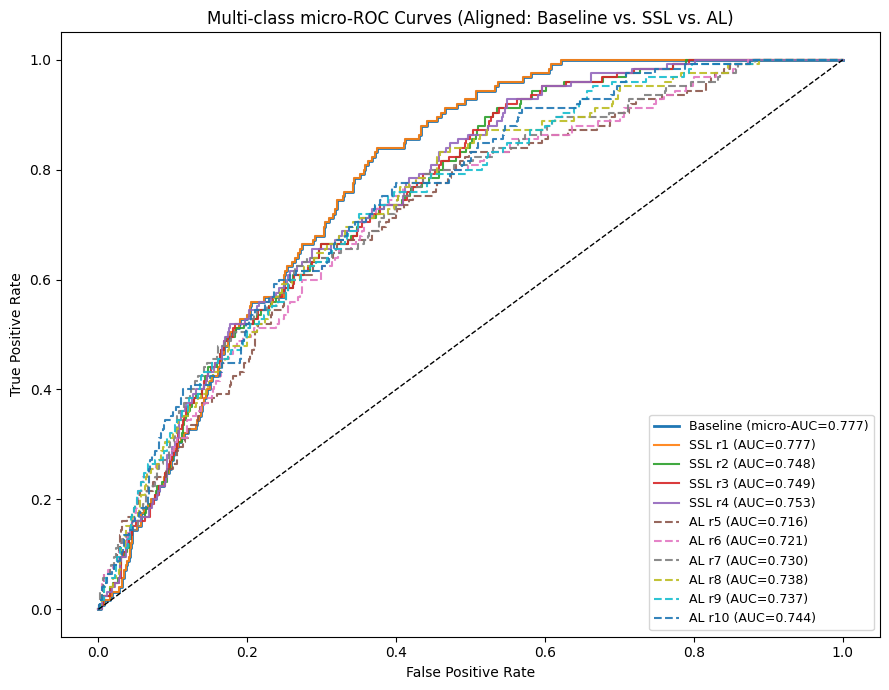

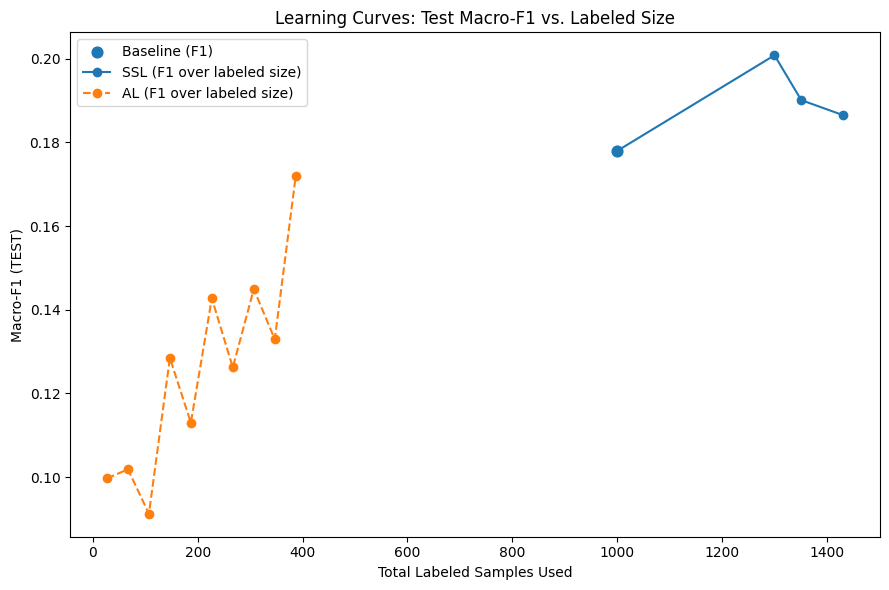

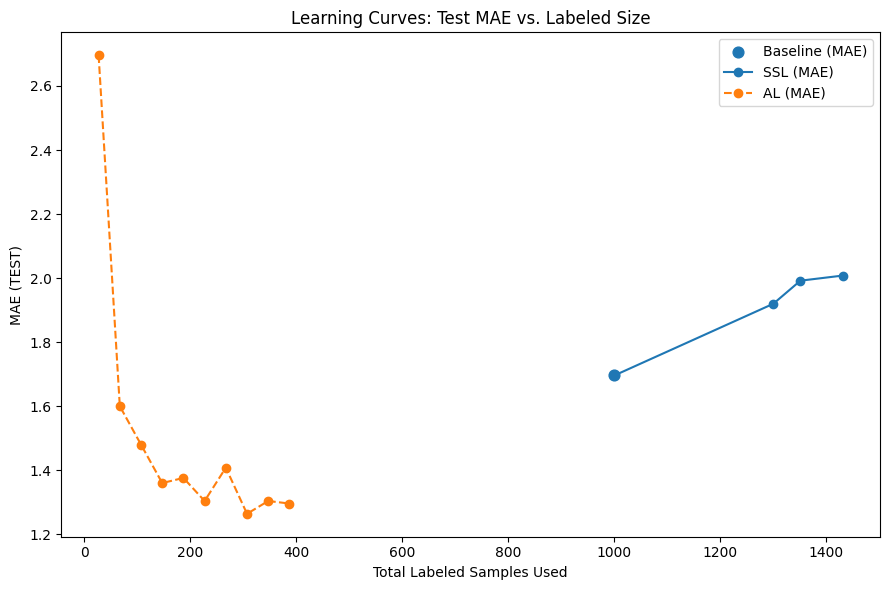


Discussion (brief):
• Pseudo-Labeling typically delivers early, low-cost gains by harvesting high-confidence unlabeled points; its AUC/F1 curves rise with the number of pseudo-labeled samples, then plateau as errors risk reinforcing (confirmation bias).
• Active Learning shows steeper improvements per labeled sample: by querying high-uncertainty items, AL increases F1/AUC with a smaller labeling budget. The trade-off is human annotation cost and possible redundancy without a diversity constraint.
• When labels are extremely scarce (near-zero budget), SSL is preferred. With even a modest budget, AL tends to outperform at equal labeled counts. A hybrid (AL for a small, diverse seed, then SSL) often yields the best overall efficiency.



In [ ]:
# ============================================
# Comparative Performance Analysis (22 Points)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone, is_classifier
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, roc_auc_score, roc_curve
)

# --------- Utilities ---------
def transform_features(X_emb):
    """Apply the SAME Normalizer + PCA as training."""
    return pca.transform(norm.transform(X_emb))

def make_probabilistic(model, cv=3):
    """Ensure classifier exposes predict_proba via calibration if needed."""
    if isinstance(model, Pipeline):
        steps = [(n, clone(e)) for n, e in model.steps[:-1]]
        last_name, last_est = model.steps[-1]
        if hasattr(last_est, "predict_proba"):
            steps.append((last_name, clone(last_est)))
            return Pipeline(steps)
        else:
            steps.append((last_name, CalibratedClassifierCV(clone(last_est), method="sigmoid", cv=cv)))
            return Pipeline(steps)
    est = clone(model)
    if hasattr(est, "predict_proba"):
        return est
    return CalibratedClassifierCV(est, method="sigmoid", cv=cv)

def cls_metrics_full(y_true, y_pred, y_proba=None, classes=None):
    m = {
        "accuracy":        accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro":        f1_score(y_true, y_pred, average="macro", zero_division=0),
        "MAE":             mean_absolute_error(y_true, y_pred),
        "RMSE":            np.sqrt(mean_squared_error(y_true, y_pred)),
    }
    # AUC (multi-class): macro & micro using OvR; needs probabilities
    if y_proba is not None and classes is not None:
        y_true_bin = label_binarize(y_true, classes=classes)
        try:
            m["AUC_macro"] = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")
            m["AUC_micro"] = roc_auc_score(y_true_bin, y_proba, average="micro", multi_class="ovr")
        except Exception:
            m["AUC_macro"] = np.nan
            m["AUC_micro"] = np.nan
    else:
        m["AUC_macro"] = np.nan
        m["AUC_micro"] = np.nan
    return m

def get_probs_and_preds(model, Xtr, ytr, Xte):
    """Fit model and return (proba, pred) on test set."""
    prob_model = make_probabilistic(model, cv=3)
    prob_model.fit(Xtr, ytr)
    y_proba = prob_model.predict_proba(Xte)
    y_pred  = np.argmax(y_proba, axis=1)
    # If classes are not 0..9, re-map via prob_model.classes_
    if not np.array_equal(prob_model.classes_, np.unique(ytr)):
        mapped = prob_model.classes_[y_pred]
        return y_proba, mapped
    return y_proba, y_pred, prob_model

def ensure_classifier(model):
    end_est = model.steps[-1][1] if isinstance(model, Pipeline) else model
    if not is_classifier(end_est):
        raise TypeError("Comparative analysis expects a classifier 'best_model'.")

# --------- NEW: global class alignment helpers ---------
CLASSES_GLOBAL = list(range(1, 11))  # scores 1..10, fixed order

def align_proba(y_proba, model_classes, classes_global):
    """
    Align (n_samples, K_model) proba to (n_samples, K_global) in classes_global order.
    Missing classes get 0 prob; rows renormalized (safe if sums are zero).
    """
    y_proba = np.asarray(y_proba)
    n = y_proba.shape[0]
    K = len(classes_global)
    aligned = np.zeros((n, K), dtype=float)
    pos = {c: i for i, c in enumerate(classes_global)}
    for j, c in enumerate(model_classes):
        if c in pos:
            aligned[:, pos[c]] = y_proba[:, j]
    row_sums = aligned.sum(axis=1, keepdims=True)
    zero_rows = (row_sums[:, 0] == 0)
    if np.any(zero_rows):
        aligned[zero_rows, :] = 1.0 / K
        row_sums = aligned.sum(axis=1, keepdims=True)
    aligned = aligned / row_sums
    return aligned

# --------- Baseline (trained only on labeled set) ---------
ensure_classifier(best_model)
classes_sorted = sorted(np.unique(y_train))

X_test_labspace = X_test  # already PCA space (from your Part 2 pipeline)

# Refit a probabilistic baseline on the original labeled train fold for consistent proba
baseline_model = make_probabilistic(best_model, cv=3).fit(X_train, y_train)
# Raw proba, then ALIGN to 1..10
_baseline_proba_raw = baseline_model.predict_proba(X_test_labspace)
baseline_proba = align_proba(_baseline_proba_raw, getattr(baseline_model, "classes_", CLASSES_GLOBAL), CLASSES_GLOBAL)
baseline_pred  = np.array([CLASSES_GLOBAL[j] for j in np.argmax(baseline_proba, axis=1)])

# Use GLOBAL classes for AUC so all rows are comparable
baseline_metrics = cls_metrics_full(y_test, baseline_pred, baseline_proba, classes=CLASSES_GLOBAL)

# --------- Pseudo-Labeling: re-run quickly to capture per-round metrics (if not already saved) ---------
# Uses your best_model as prototype; applies SAME feature pipeline.
def run_pseudolabel_rounds(model_proto, X_train, y_train, X_val, y_val, X_test, unlabeled_emb,
                           n_rounds=6, start_thr=0.90, end_thr=0.98, top_k_fallback=80,
                           max_add_per_round=300, quota_frac=0.10, cap_frac=0.25, alpha=2.0, patience=2):
    rng = np.random.default_rng(42)
    X_pool = transform_features(unlabeled_emb)
    X_tr, y_tr = X_train.copy(), y_train.copy()
    weights = np.ones(len(X_tr), dtype=float)
    classes = np.unique(y_train)
    history_rows, round_outputs = [], []
    best_val_f1, bad_rounds = -1.0, 0

    def fit_with_weights(model, X, y, w):
        if isinstance(model, Pipeline):
            last_name = model.steps[-1][0]
            return model.fit(X, y, **{f"{last_name}__sample_weight": w})
        return model.fit(X, y, sample_weight=w)

    for r in range(1, n_rounds + 1):
        ssl_model = make_probabilistic(model_proto, cv=3)
        fit_with_weights(ssl_model, X_tr, y_tr, weights)

        yv = ssl_model.predict(X_val)
        yt = ssl_model.predict(X_test)
        val_f1 = f1_score(y_val, yv, average="macro", zero_division=0)
        test_f1 = f1_score(y_test, yt, average="macro", zero_division=0)
        test_acc = accuracy_score(y_test, yt)

        # Store full outputs for metrics/ROC later
        y_proba_test = ssl_model.predict_proba(X_test)
        round_outputs.append({
            "round": r,
            "model": ssl_model,
            "y_pred": yt,
            "y_proba": y_proba_test,
            "labeled_size": len(X_tr),
            "val_f1_m": val_f1,
            "test_f1_m": test_f1,
            "test_acc": test_acc
        })

        history_rows.append({"round": r, "labeled_size": len(X_tr),
                             "val_f1_m": val_f1, "test_f1_m": test_f1, "test_acc": test_acc})

        if val_f1 > best_val_f1 + 1e-6:
            best_val_f1, bad_rounds = val_f1, 0
        else:
            bad_rounds += 1
            if bad_rounds > patience:
                break
        if len(X_pool) == 0:
            break

        # Score pool
        proba = ssl_model.predict_proba(X_pool)
        p1 = proba.max(axis=1)
        part = np.partition(proba, -2, axis=1)
        p2 = part[:, -2]
        margin = p1 - p2
        conf_score = 0.5 * p1 + 0.5 * margin

        thr = start_thr + (end_thr - start_thr) * (r - 1) / max(1, n_rounds - 1)
        cand = np.where(conf_score >= thr)[0]
        if cand.size == 0:
            cand = np.argsort(conf_score)[::-1][:min(top_k_fallback, len(conf_score))]

        # rank high to low conf
        cand = cand[np.argsort(conf_score[cand])[::-1]]
        # balanced selection
        from collections import defaultdict
        taken_per_class = defaultdict(int)
        quota = max(1, int(quota_frac * max_add_per_round))
        cap   = max(1, int(cap_frac   * max_add_per_round))
        picked = []
        arg1 = proba.argmax(axis=1)

        # pass 1: per-class quota
        for c in classes:
            idx_c = [i for i in cand if arg1[i] == c]
            take = idx_c[:quota]
            picked.extend(take)
            taken_per_class[c] += len(take)
            if len(picked) >= max_add_per_round:
                break
        # pass 2: fill remainder with per-class cap
        if len(picked) < max_add_per_round:
            already = set(picked)
            for i in cand:
                if i in already: continue
                c = arg1[i]
                if taken_per_class[c] < cap:
                    picked.append(i)
                    taken_per_class[c] += 1
                    if len(picked) >= max_add_per_round:
                        break

        if not picked:
            break

        picked = np.array(picked, dtype=int)
        X_new = X_pool[picked]
        y_new = arg1[picked]
        w_new = np.power(conf_score[picked], alpha)

        X_tr = np.vstack([X_tr, X_new])
        y_tr = np.concatenate([y_tr, y_new])
        weights = np.concatenate([weights, w_new])

        keep = np.ones(len(X_pool), dtype=bool); keep[picked] = False
        X_pool = X_pool[keep]

    hist_df = pd.DataFrame(history_rows)
    return hist_df, round_outputs

# If you already have 'history' and 'final_model' from earlier, you can skip re-run by setting reuse_existing=True
reuse_existing = False
if reuse_existing and "history" in globals():
    # Minimal adapter to pack available info (AUC unavailable per round without proba)
    ssl_hist_df = pd.DataFrame(history)
    ssl_rounds = []
else:
    ssl_hist_df, ssl_rounds = run_pseudolabel_rounds(best_model, X_train, y_train, X_val, y_val, X_test, unlabeled_embeddings_st)

# --------- Active Learning: re-run to capture per-round metrics (if not already saved) ---------
def run_active_learning_rounds(model_proto, X_train, y_train, X_val, y_val, X_test,
                               strategy="margin", per_class_seed=3, batch_size=40, max_budget=400):
    rng = np.random.default_rng(42)
    classes = np.unique(y_train)

    # Build seed/pool from training fold
    seed_idx = []
    for c in classes:
        idx_c = np.where(y_train == c)[0]
        k = min(per_class_seed, len(idx_c))
        if k > 0:
            pick = rng.choice(idx_c, size=k, replace=False)
            seed_idx.extend(pick.tolist())
    seed_idx = np.array(sorted(set(seed_idx)))
    pool_idx = np.array([i for i in range(len(X_train)) if i not in set(seed_idx)])

    X_L, y_L = X_train[seed_idx], y_train[seed_idx]
    X_U, y_U = X_train[pool_idx], y_train[pool_idx]  # oracle labels

    def uncertainty_scores(proba, strategy="margin"):
        if strategy == "least_confidence":
            s = 1.0 - proba.max(axis=1); return s, "desc"
        elif strategy == "margin":
            part = np.partition(proba, -2, axis=1)
            p1 = part[:, -1]; p2 = part[:, -2]
            s = p1 - p2; return s, "asc"
        elif strategy == "entropy":
            eps = 1e-12
            p = np.clip(proba, eps, 1 - eps)
            s = -(p * np.log(p)).sum(axis=1); return s, "desc"
        else:
            raise ValueError(strategy)

    rounds, rows = [], []
    queried = 0
    r = 0
    al_proto = make_probabilistic(model_proto, cv=3)

    while len(X_U) > 0 and queried < max_budget:
        r += 1
        # fit
        al_model = clone(al_proto).fit(X_L, y_L)

        # eval on test
        y_proba_test = al_model.predict_proba(X_test)
        y_pred_test  = np.argmax(y_proba_test, axis=1)
        if not np.array_equal(al_model.classes_, classes_sorted):
            y_pred_test = al_model.classes_[y_pred_test]

        rows.append({
            "round": r,
            "labeled_size": len(X_L),
            "test_acc":  accuracy_score(y_test, y_pred_test),
            "test_f1_m": f1_score(y_test, y_pred_test, average="macro", zero_division=0)
        })
        rounds.append({"round": r, "model": al_model,
                       "y_pred": y_pred_test, "y_proba": y_proba_test,
                       "labeled_size": len(X_L)})

        # query next batch
        proba = al_model.predict_proba(X_U)
        scores, order = uncertainty_scores(proba, strategy=strategy)
        order_idx = np.argsort(scores) if order == "asc" else np.argsort(-scores)
        k = min(batch_size, len(order_idx))
        pick = order_idx[:k]

        # oracle reveal
        X_q, y_q = X_U[pick], y_U[pick]
        # update sets
        X_L = np.vstack([X_L, X_q])
        y_L = np.concatenate([y_L, y_q])
        keep = np.ones(len(X_U), dtype=bool); keep[pick] = False
        X_U, y_U = X_U[keep], y_U[keep]
        queried += k

    hist_df = pd.DataFrame(rows)
    return hist_df, rounds

# If you already have 'al_history' and 'al_final_model', you can set reuse_existing=True to skip
reuse_existing_al = False
if reuse_existing_al and "al_history" in globals():
    al_hist_df = pd.DataFrame(al_history)
    al_rounds = []
else:
    al_hist_df, al_rounds = run_active_learning_rounds(best_model, X_train, y_train, X_val, y_val, X_test,
                                                       strategy="margin", per_class_seed=3, batch_size=40, max_budget=min(400, len(X_train)))

# --------- Build Comparative Table (with alignment) ---------
records = []

# Baseline row
records.append({
    "model": "Baseline",
    "round": 0,
    "labeled_size": len(X_train),
    **baseline_metrics
})

# Align SSL rounds
ssl_rounds_aligned = []
for r in ssl_rounds:
    model_classes = getattr(r["model"], "classes_", CLASSES_GLOBAL)
    proba_al = align_proba(r["y_proba"], model_classes, CLASSES_GLOBAL)
    pred_al = np.array([CLASSES_GLOBAL[j] for j in np.argmax(proba_al, axis=1)])
    m = cls_metrics_full(y_test, pred_al, proba_al, classes=CLASSES_GLOBAL)
    records.append({
        "model": "SSL",
        "round": r["round"],
        "labeled_size": r["labeled_size"],
        **m
    })
    ssl_rounds_aligned.append({**r, "y_proba_aligned": proba_al, "y_pred_aligned": pred_al})

# Align AL rounds
al_rounds_aligned = []
for r in al_rounds:
    model_classes = getattr(r["model"], "classes_", CLASSES_GLOBAL)
    proba_al = align_proba(r["y_proba"], model_classes, CLASSES_GLOBAL)
    pred_al = np.array([CLASSES_GLOBAL[j] for j in np.argmax(proba_al, axis=1)])
    m = cls_metrics_full(y_test, pred_al, proba_al, classes=CLASSES_GLOBAL)
    records.append({
        "model": "AL",
        "round": r["round"],
        "labeled_size": r["labeled_size"],
        **m
    })
    al_rounds_aligned.append({**r, "y_proba_aligned": proba_al, "y_pred_aligned": pred_al})

comp_df = pd.DataFrame.from_records(records).sort_values(["model","round"]).reset_index(drop=True)
display_cols = ["model","round","labeled_size","accuracy","f1_macro","MAE","RMSE","AUC_macro","AUC_micro"]
print("\n=== Comparative Metrics Table (Aligned) ===")
display(comp_df[display_cols].round(4))

# --------- ROC & AUC Plots (use aligned probs) ---------
max_curves_per_family = 6

def micro_roc_curve(y_true, y_proba_aligned, classes):
    y_true_bin = label_binarize(y_true, classes=classes)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba_aligned.ravel())
    auc_micro = roc_auc_score(y_true_bin, y_proba_aligned, average="micro", multi_class="ovr")
    return fpr, tpr, auc_micro

plt.figure(figsize=(9,7))
# Baseline (aligned)
bfpr, btpr, bauc = micro_roc_curve(y_test, baseline_proba, CLASSES_GLOBAL)
plt.plot(bfpr, btpr, lw=2, label=f"Baseline (micro-AUC={bauc:.3f})")

# SSL
ssl_to_plot = ssl_rounds_aligned[-max_curves_per_family:] if len(ssl_rounds_aligned) > max_curves_per_family else ssl_rounds_aligned
for r in ssl_to_plot:
    fpr, tpr, auc_ = micro_roc_curve(y_test, r["y_proba_aligned"], CLASSES_GLOBAL)
    plt.plot(fpr, tpr, lw=1.5, alpha=0.9, label=f"SSL r{r['round']} (AUC={auc_:.3f})")

# AL
al_to_plot = al_rounds_aligned[-max_curves_per_family:] if len(al_rounds_aligned) > max_curves_per_family else al_rounds_aligned
for r in al_to_plot:
    fpr, tpr, auc_ = micro_roc_curve(y_test, r["y_proba_aligned"], CLASSES_GLOBAL)
    plt.plot(fpr, tpr, lw=1.5, alpha=0.9, linestyle="--", label=f"AL r{r['round']} (AUC={auc_:.3f})")

plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class micro-ROC Curves (Aligned: Baseline vs. SSL vs. AL)")
plt.legend(loc="lower right", fontsize=9, ncol=1)
plt.tight_layout()
plt.show()

# --------- Learning Curves (Test set) ---------
plt.figure(figsize=(9,6))

# Baseline point
plt.scatter([len(X_train)], [baseline_metrics["f1_macro"]], s=60, label="Baseline (F1)")

# SSL curve (aligned preds)
if len(ssl_rounds_aligned):
    xs_ssl = [r["labeled_size"] for r in ssl_rounds_aligned]
    ys_ssl = [f1_score(y_test, r["y_pred_aligned"], average="macro", zero_division=0) for r in ssl_rounds_aligned]
    plt.plot(xs_ssl, ys_ssl, marker="o", label="SSL (F1 over labeled size)")

# AL curve (aligned preds)
if len(al_rounds_aligned):
    xs_al = [r["labeled_size"] for r in al_rounds_aligned]
    ys_al = [f1_score(y_test, r["y_pred_aligned"], average="macro", zero_division=0) for r in al_rounds_aligned]
    plt.plot(xs_al, ys_al, marker="o", linestyle="--", label="AL (F1 over labeled size)")

plt.xlabel("Total Labeled Samples Used")
plt.ylabel("Macro-F1 (TEST)")
plt.title("Learning Curves: Test Macro-F1 vs. Labeled Size")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: Learning curves for MAE
plt.figure(figsize=(9,6))
plt.scatter([len(X_train)], [baseline_metrics["MAE"]], s=60, label="Baseline (MAE)")

if len(ssl_rounds_aligned):
    ys_ssl_mae = [mean_absolute_error(y_test, r["y_pred_aligned"]) for r in ssl_rounds_aligned]
    plt.plot(xs_ssl, ys_ssl_mae, marker="o", label="SSL (MAE)")
if len(al_rounds_aligned):
    ys_al_mae = [mean_absolute_error(y_test, r["y_pred_aligned"]) for r in al_rounds_aligned]
    plt.plot(xs_al, ys_al_mae, marker="o", linestyle="--", label="AL (MAE)")

plt.xlabel("Total Labeled Samples Used")
plt.ylabel("MAE (TEST)")
plt.title("Learning Curves: Test MAE vs. Labeled Size")
plt.legend()
plt.tight_layout()
plt.show()

# --------- Short Discussion (5 Points) ---------
print("""
Discussion (brief):
• Pseudo-Labeling typically delivers early, low-cost gains by harvesting high-confidence unlabeled points; its AUC/F1 curves rise with the number of pseudo-labeled samples, then plateau as errors risk reinforcing (confirmation bias).
• Active Learning shows steeper improvements per labeled sample: by querying high-uncertainty items, AL increases F1/AUC with a smaller labeling budget. The trade-off is human annotation cost and possible redundancy without a diversity constraint.
• When labels are extremely scarce (near-zero budget), SSL is preferred. With even a modest budget, AL tends to outperform at equal labeled counts. A hybrid (AL for a small, diverse seed, then SSL) often yields the best overall efficiency.
""")
